# Marketing Attribution / MMM (Marketing Mix Modeling)

This notebook is built for a measurement and attribution use case:
- multi-channel campaign data
- channel contribution
- ROI per channel
- regression + time-series modeling

> Beginner note: MMM is usually best for **aggregate channel impact over time**, not user-level attribution.

## 1. Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

import statsmodels.api as sm

np.random.seed(42)
sns.set(style='whitegrid')

## 2. Load GA-Style CSV (Preferred) or Simulate Data

This notebook first tries to load real marketing CSV data, then falls back to simulation.

### Supported CSV patterns

1. **Wide format** (already daily):
- `date`, `revenue`, `spend_search`, `spend_social`, `spend_display`, `spend_email`

2. **Long format** (channel rows):
- `date`, `channel`, `spend`, and optionally `revenue`

> Beginner note: GA exports often need joining with ad-platform spend before MMM.

In [2]:
def adstock(x, alpha=0.5):
    out = np.zeros(len(x))
    out[0] = x[0]
    for i in range(1, len(x)):
        out[i] = x[i] + alpha * out[i - 1]
    return out

def normalize_channel_name(s):
    txt = str(s).strip().lower()
    if 'search' in txt:
        return 'search'
    if 'social' in txt or 'facebook' in txt or 'instagram' in txt or 'tiktok' in txt:
        return 'social'
    if 'display' in txt or 'banner' in txt:
        return 'display'
    if 'email' in txt or 'newsletter' in txt:
        return 'email'
    return 'other'

ga_candidates = [
    Path('data/marketing_attribution.csv'),
    Path('data/ga_marketing_data.csv'),
    Path('data/google_analytics_marketing.csv'),
    Path('datasets/marketing_attribution.csv'),
]
ga_path = next((p for p in ga_candidates if p.exists()), None)

if ga_path is not None:
    print(f'Using real marketing CSV: {ga_path}')
    raw = pd.read_csv(ga_path)
    raw.columns = [c.strip() for c in raw.columns]
    lower_cols = {c.lower(): c for c in raw.columns}

    if 'date' not in lower_cols:
        raise ValueError('CSV must include a `date` column for MMM.')

    date_col = lower_cols['date']
    raw[date_col] = pd.to_datetime(raw[date_col])

    # Case A: wide format already has spend_search/spend_social/spend_display/spend_email + revenue
    spend_wide_cols = ['spend_search', 'spend_social', 'spend_display', 'spend_email']
    has_wide = all(col in raw.columns for col in spend_wide_cols)
    has_revenue = 'revenue' in lower_cols

    if has_wide and has_revenue:
        df = raw.copy()
        df = df.rename(columns={date_col: 'date', lower_cols['revenue']: 'revenue'})
        df = df[['date', 'revenue', 'spend_search', 'spend_social', 'spend_display', 'spend_email']].copy()
        df = df.groupby('date', as_index=False).sum()
    else:
        # Case B: long format: date, channel, spend (+ optional revenue)
        if 'channel' not in lower_cols:
            raise ValueError(
                'CSV not recognized. Provide either wide spend columns or long format with `channel` + `spend`.'
            )
        if 'spend' not in lower_cols:
            raise ValueError('Long format requires a `spend` column.')

        channel_col = lower_cols['channel']
        spend_col = lower_cols['spend']
        raw['channel_norm'] = raw[channel_col].apply(normalize_channel_name)

        spend_daily = (
            raw.pivot_table(index=date_col, columns='channel_norm', values=spend_col, aggfunc='sum', fill_value=0)
            .reset_index()
            .rename(columns={date_col: 'date'})
        )

        for c in ['search', 'social', 'display', 'email']:
            if c not in spend_daily.columns:
                spend_daily[c] = 0.0

        spend_daily = spend_daily.rename(
            columns={
                'search': 'spend_search',
                'social': 'spend_social',
                'display': 'spend_display',
                'email': 'spend_email',
            }
        )

        if has_revenue:
            revenue_col = lower_cols['revenue']
            revenue_daily = raw.groupby(date_col, as_index=False)[revenue_col].sum().rename(columns={date_col: 'date', revenue_col: 'revenue'})
            df = spend_daily.merge(revenue_daily, on='date', how='left')
        elif 'conversions' in lower_cols:
            conv_col = lower_cols['conversions']
            # Simple fallback: conversions -> revenue proxy
            assumed_aov = 120.0
            revenue_daily = (
                raw.groupby(date_col, as_index=False)[conv_col].sum()
                .assign(revenue=lambda d: d[conv_col] * assumed_aov)
                .rename(columns={date_col: 'date'})[['date', 'revenue']]
            )
            df = spend_daily.merge(revenue_daily, on='date', how='left')
            print(f'No revenue column found. Using conversions x assumed AOV={assumed_aov} as revenue proxy.')
        else:
            raise ValueError('Need either `revenue` or `conversions` column to build MMM target.')

    df = df.sort_values('date').reset_index(drop=True)
    df['day_idx'] = np.arange(len(df))
    df['dow'] = df['date'].dt.dayofweek

else:
    print('No GA-style CSV found. Falling back to simulated campaign data.')
    n_days = 365
    dates = pd.date_range('2025-01-01', periods=n_days, freq='D')

    df = pd.DataFrame({'date': dates})
    df['day_idx'] = np.arange(n_days)
    df['dow'] = df['date'].dt.dayofweek

    # Channel spend (daily)
    df['spend_search'] = np.random.gamma(shape=6, scale=60, size=n_days)
    df['spend_social'] = np.random.gamma(shape=5, scale=45, size=n_days)
    df['spend_display'] = np.random.gamma(shape=4, scale=35, size=n_days)
    df['spend_email'] = np.random.gamma(shape=2, scale=12, size=n_days)

    # Weekly seasonality and trend
    weekly = 120 * np.sin(2 * np.pi * df['day_idx'] / 7)
    trend = 1.5 * df['day_idx']

    # True (simulated) revenue-generating process
    base_revenue = 2200
    noise = np.random.normal(0, 180, size=n_days)

    df['ad_search'] = adstock(df['spend_search'].values, alpha=0.65)
    df['ad_social'] = adstock(df['spend_social'].values, alpha=0.55)
    df['ad_display'] = adstock(df['spend_display'].values, alpha=0.45)
    df['ad_email'] = adstock(df['spend_email'].values, alpha=0.30)

    df['revenue'] = (
        base_revenue
        + 0.32 * df['ad_search']
        + 0.22 * df['ad_social']
        + 0.11 * df['ad_display']
        + 0.18 * df['ad_email']
        + weekly
        + trend
        + noise
    ).clip(lower=0)

# Apply adstock consistently (for real and simulated data)
df['ad_search'] = adstock(df['spend_search'].values, alpha=0.65)
df['ad_social'] = adstock(df['spend_social'].values, alpha=0.55)
df['ad_display'] = adstock(df['spend_display'].values, alpha=0.45)
df['ad_email'] = adstock(df['spend_email'].values, alpha=0.30)

df['revenue'] = pd.to_numeric(df['revenue'], errors='coerce').fillna(0)
for c in ['spend_search', 'spend_social', 'spend_display', 'spend_email']:
    df[c] = pd.to_numeric(df[c], errors='coerce').fillna(0)

print({'rows': len(df), 'date_min': str(df['date'].min().date()), 'date_max': str(df['date'].max().date())})
df.head()

Using real marketing CSV: data/marketing_attribution.csv
{'rows': 200, 'date_min': '2025-01-01', 'date_max': '2025-07-19'}


,date,revenue,spend_search,spend_social,spend_display,spend_email,day_idx,dow,ad_search,ad_social,ad_display,ad_email
0,2025-01-01,22100.0,230.1,37.8,69.2,9.13,0,2,230.100000,37.800000,69.20000,9.130000
1,2025-01-02,10400.0,44.5,39.3,45.1,8.15,1,3,194.065000,60.090000,76.24000,10.889000
2,2025-01-03,9300.0,17.2,45.9,69.3,10.35,2,4,143.342250,78.949500,103.60800,13.616700
3,2025-01-04,18500.0,151.5,41.3,58.5,9.12,3,5,244.672462,84.722225,105.12360,13.205010
4,2025-01-05,12900.0,180.8,10.8,58.4,4.54,4,6,339.837101,57.397224,105.70562,8.501503


## 3. Quick EDA

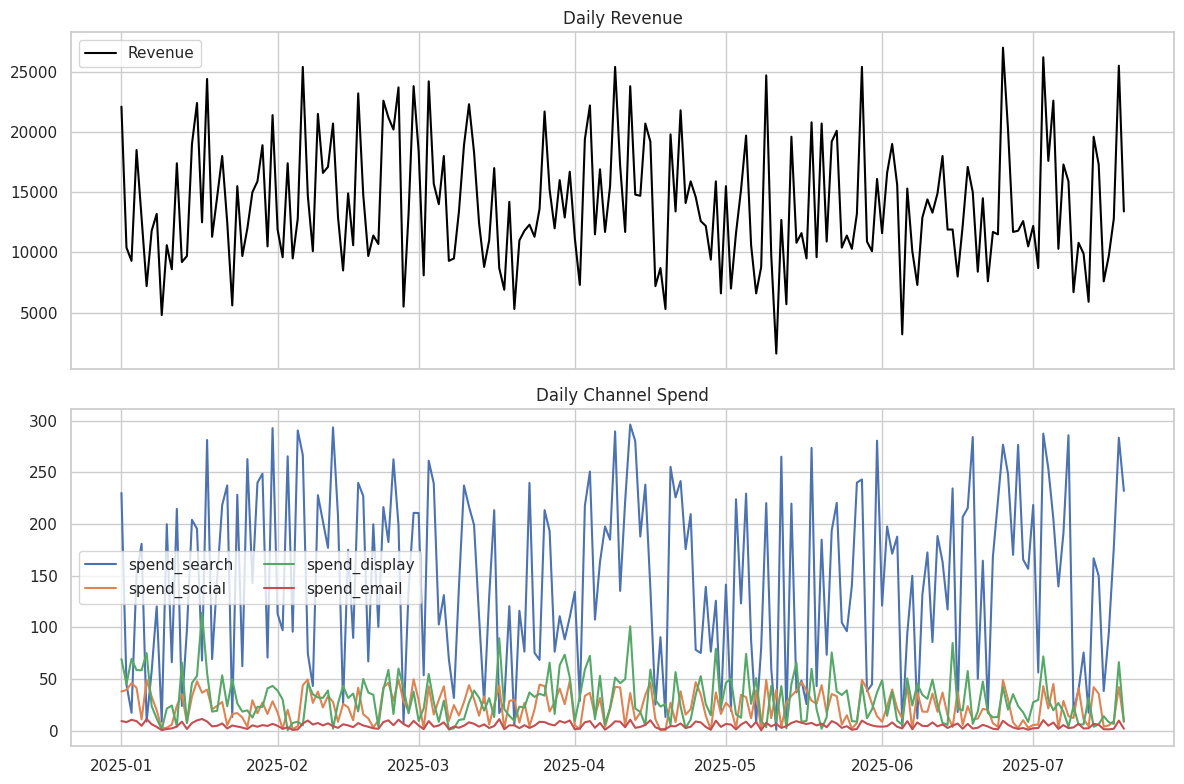

In [3]:
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
axes[0].plot(df['date'], df['revenue'], label='Revenue', color='black')
axes[0].set_title('Daily Revenue')
axes[0].legend()

for col in ['spend_search', 'spend_social', 'spend_display', 'spend_email']:
    axes[1].plot(df['date'], df[col], label=col)
axes[1].set_title('Daily Channel Spend')
axes[1].legend(ncol=2)
plt.tight_layout()
plt.show()

## 4. Model A: Regression MMM

> Beginner note: this is a practical baseline that many teams start with before advanced Bayesian MMM.

In [4]:
feature_cols = ['ad_search', 'ad_social', 'ad_display', 'ad_email', 'day_idx']
X = df[feature_cols].copy()
y = df['revenue'].copy()

split_idx = int(len(df) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

reg = LinearRegression()
reg.fit(X_train, y_train)

pred_test = reg.predict(X_test)
print('Regression MMM metrics:')
print({'r2': round(r2_score(y_test, pred_test), 4), 'mae': round(mean_absolute_error(y_test, pred_test), 2)})

coef_df = pd.DataFrame({'feature': feature_cols, 'coefficient': reg.coef_}).sort_values('coefficient', ascending=False)
coef_df

Regression MMM metrics:
{'r2': 0.6603, 'mae': 2479.22}


,feature,coefficient
3,ad_email,1972.394996
0,ad_search,25.362147
4,day_idx,-2.471548
2,ad_display,-90.387635
1,ad_social,-132.732443


## 5. Channel Contribution + ROI (Regression-Based)

Contribution is approximated by coefficient × adstocked spend.

In [5]:
channel_map = {
    'search': 'ad_search',
    'social': 'ad_social',
    'display': 'ad_display',
    'email': 'ad_email',
}

coef_lookup = dict(zip(feature_cols, reg.coef_))
summary_rows = []

for channel, ad_col in channel_map.items():
    contrib = (coef_lookup[ad_col] * df[ad_col]).sum()
    spend_col = f'spend_{channel}'
    total_spend = df[spend_col].sum()
    roi = contrib / total_spend if total_spend > 0 else np.nan
    summary_rows.append({
        'channel': channel,
        'estimated_contribution': contrib,
        'total_spend': total_spend,
        'estimated_roi': roi,
    })

channel_roi_reg = pd.DataFrame(summary_rows).sort_values('estimated_roi', ascending=False)
channel_roi_reg

,channel,estimated_contribution,total_spend,estimated_roi
3,email,2.823380e+06,1003.46,2813.644759
0,search,2.104483e+06,29408.50,71.560371
2,display,-1.001196e+06,6110.80,-163.840436
1,social,-1.366059e+06,4652.80,-293.599326


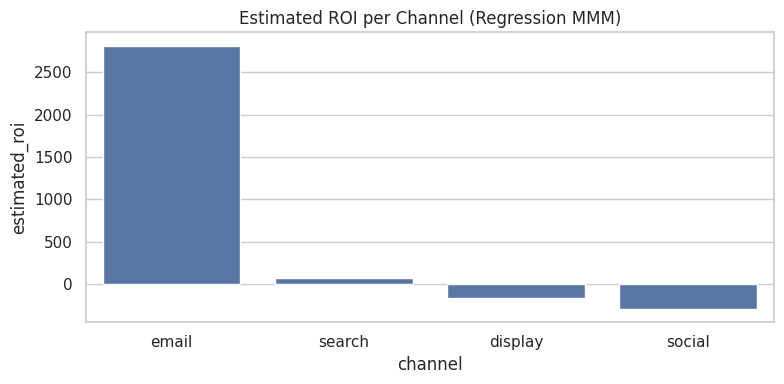

In [6]:
plt.figure(figsize=(8, 4))
sns.barplot(data=channel_roi_reg, x='channel', y='estimated_roi')
plt.title('Estimated ROI per Channel (Regression MMM)')
plt.tight_layout()
plt.show()

## 6. Model B: Time-Series with Exogenous Marketing Inputs (SARIMAX)

This captures temporal structure while still measuring channel effect.

In [7]:
ts_df = df.set_index('date').copy()
exog_cols = ['ad_search', 'ad_social', 'ad_display', 'ad_email']

train_ts = ts_df.iloc[:split_idx]
test_ts = ts_df.iloc[split_idx:]

sarimax = sm.tsa.statespace.SARIMAX(
    train_ts['revenue'],
    exog=train_ts[exog_cols],
    order=(1, 0, 1),
    seasonal_order=(1, 0, 1, 7),
    enforce_stationarity=False,
    enforce_invertibility=False,
)
sarimax_fit = sarimax.fit(disp=False)

pred_ts = sarimax_fit.predict(
    start=test_ts.index[0],
    end=test_ts.index[-1],
    exog=test_ts[exog_cols],
)

print('SARIMAX metrics:')
print({'r2': round(r2_score(test_ts['revenue'], pred_ts), 4), 'mae': round(mean_absolute_error(test_ts['revenue'], pred_ts), 2)})

sarimax_fit.params.head(20)

SARIMAX metrics:
{'r2': 0.6487, 'mae': 2558.63}


/usr/local/lib/python3.8/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.8/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


ad_search     2.706620e+01
ad_social    -1.107891e+02
ad_display   -8.375247e+01
ad_email      1.838321e+03
ar.L1        -9.932687e-01
ma.L1         9.946977e-01
ar.S.L7      -1.651969e-03
ma.S.L7       1.842703e-02
sigma2        9.673865e+06
dtype: float64

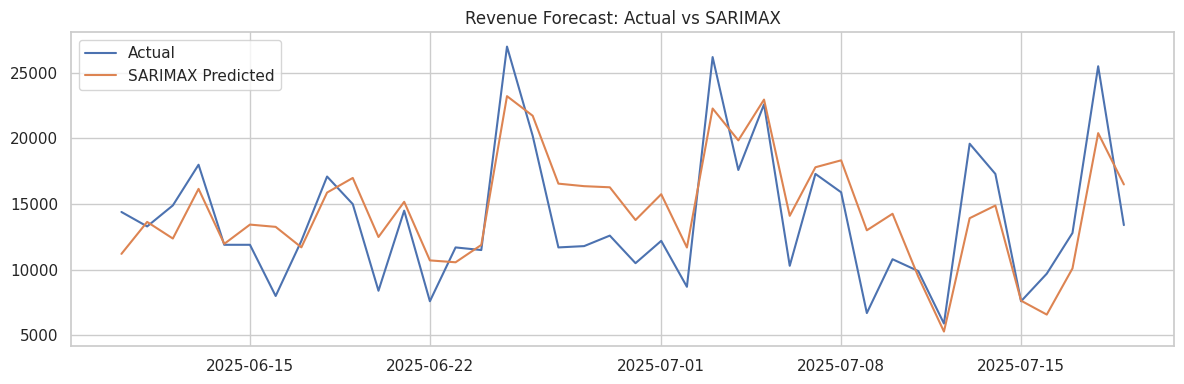

In [8]:
plt.figure(figsize=(12, 4))
plt.plot(test_ts.index, test_ts['revenue'], label='Actual')
plt.plot(test_ts.index, pred_ts, label='SARIMAX Predicted')
plt.title('Revenue Forecast: Actual vs SARIMAX')
plt.legend()
plt.tight_layout()
plt.show()

## 7. Attribution Summary

Answer the core business question: **Which channels actually drive revenue?**

In [9]:
reg_ranking = channel_roi_reg[['channel', 'estimated_roi']].copy()
reg_ranking['rank'] = reg_ranking['estimated_roi'].rank(ascending=False, method='dense').astype(int)
reg_ranking = reg_ranking.sort_values('rank')
reg_ranking

,channel,estimated_roi,rank
3,email,2813.644759,1
0,search,71.560371,2
2,display,-163.840436,3
1,social,-293.599326,4


## 8. Key Learning

- MMM helps estimate **channel contribution** and **ROI** from aggregate time-series data.
- Regression gives a fast, interpretable baseline for contribution and ROI.
- Time-series models (SARIMAX here) improve realism by modeling trend/seasonality dynamics.
- Use this output to guide channel budget shifts toward higher incremental return.

> Next step suggestion: add saturation curves, lag tuning, and Bayesian MMM for stronger causal robustness.